# **New 1000 Sales Records Data 2**


## **Import Library**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
from sklearn.impute import KNNImputer

## **Memuat Dataset**

Sumber dataset ini berasal dari New 1000 Sales Records Data 2

In [ ]:
path = '/content/drive/MyDrive/Colab Notebooks/Cekpoint/New 1000 Sales Records.csv'

df = pd.read_csv(path)
df

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,Order year,Order Month,Order Weekday,Unit Margin,Order_Ship_Days
0,Middle East and North Africa,Libya,Cosmetics,Offline,M,2014-10-18,686800706,2014-10-31,8446,437.20,263.33,3692591.20,2224085.18,1468506.02,2014,10,fri,173.87,13 days
1,North America,Canada,Vegetables,Online,M,2011-11-07,185941302,2011-12-08,3018,154.06,90.93,464953.08,274426.74,190526.34,2011,11,sun,63.13,31 days
2,Middle East and North Africa,Libya,Baby Food,Offline,C,2016-10-31,246222341,2016-12-09,1517,255.28,159.42,387259.76,241840.14,145419.62,2016,10,sun,95.86,39 days
3,Asia,Japan,Cereal,Offline,C,2010-04-10,161442649,2010-05-12,3322,205.70,117.11,683335.40,389039.42,294295.98,2010,4,fri,88.59,32 days
4,Sub-Saharan Africa,Chad,Fruits,Offline,H,2011-08-16,645713555,2011-08-31,9845,9.33,6.92,91853.85,68127.40,23726.45,2011,8,mon,2.41,15 days
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Middle East and North Africa,Azerbaijan,Snacks,Offline,C,2010-04-18,534085166,2010-04-25,6524,152.58,97.44,995431.92,635698.56,359733.36,2010,4,sat,55.14,7 days
996,Europe,Georgia,Baby Food,Offline,H,2011-08-01,590768182,2011-09-07,288,255.28,159.42,73520.64,45912.96,27607.68,2011,8,sun,95.86,37 days
997,Middle East and North Africa,United Arab Emirates,Vegetables,Online,C,2011-05-12,524363124,2011-06-28,9556,154.06,90.93,1472197.36,868927.08,603270.28,2011,5,wed,63.13,47 days
998,Europe,Finland,Household,Offline,L,2016-01-25,289606320,2016-02-14,9801,668.27,502.54,6549714.27,4925394.54,1624319.73,2016,1,sun,165.73,20 days


In [ ]:
df.dtypes

,0
Region,object
Country,object
Item Type,object
Sales Channel,object
Order Priority,object
Order Date,object
Order ID,int64
Ship Date,object
Units Sold,int64
Unit Price,float64


## **Business Understanding**

**1. Business Objective**

Jadi saya ingin tau meneliti dataset ini, mau liat bagaimana kinerja dari penjualan ini. saya ingin tau produk apa saja yang paling laris dan memberikan untung lebih besar, wilayah mana yang jadi penyumbang pendapatan terbanyak, juga pola penjualan dari waktu ke waktu itu bagaimana.

Saya ingin dari analisis ini saya mendapatkan gambaran tentang penjualan, agar kedepannya bisa lebih mudah untuk mencoba membuat bisnis yang tepat.

**2. Assess Situation**

Dataset ini dipakai untuk mencatat transaksi penjualan, ada juga berbagai informasi seperti tanggal pemesanan, wilayahnya dari mana, jenis barangnya, jumlah yang terjual, harga, total dari penjualannya, dan total keuntungannya. Sebelum menggunakan data ini saya memastikan apakah data ini ada yang kosong dan data yang double.

Dan juga tipe data yang dipakai harus di cek, kolom tanggal, supaya nanti bisa dipakai buat liat tren penjualan.

**3. Analytic Goals / Project Plan**

Hal yang harus dilakukan pertama-tama adalah membersihkan data atau column yang tidak diperlukan, mencari data kosong, dan pastikan tipe datanya udah betul semua.

Lalu, lanjut menganalisis datanya. contoh kita liat total penjualannya per wilayah, produk apa aja yang paling untung, bagaimana tren penjualannya dari waktu ke waktu, dll.

Terakhir, kita simpulkan dan kasih recomendasi berdasarkan hasil analisis tadi, recomendasi ini berguna untuk menyusun strategi penjualan yang berguna untuk kedepannya.

## **Data Understanding**

### **Struktur Data (Informasi Lanjutan)**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Region           1000 non-null   object 
 1   Country          1000 non-null   object 
 2   Item Type        1000 non-null   object 
 3   Sales Channel    1000 non-null   object 
 4   Order Priority   1000 non-null   object 
 5   Order Date       1000 non-null   object 
 6   Order ID         1000 non-null   int64  
 7   Ship Date        1000 non-null   object 
 8   Units Sold       1000 non-null   int64  
 9   Unit Price       1000 non-null   float64
 10  Unit Cost        1000 non-null   float64
 11  Total Revenue    1000 non-null   float64
 12  Total Cost       1000 non-null   float64
 13  Total Profit     1000 non-null   float64
 14  Order year       1000 non-null   int64  
 15  Order Month      1000 non-null   int64  
 16  Order Weekday    1000 non-null   object 
 17  Unit Margin    

1. Region : Jumlah baris: 1000, Tipe data: object, Deskripsi: Wilayah pasar tempat transaksi dilakukan

2. Country : Jumlah baris: 1000, Tipe data: object, Deskripsi: Negara tempat penjualan terjadi

3. Item Type : Jumlah baris: 1000, Tipe data: object, Deskripsi: Jenis atau kategori produk yang dijual

4. Sales Channel : Jumlah baris: 1000, Tipe data: object, Deskripsi: Saluran penjualan (Online atau Offline)

5. Order Priority : Jumlah baris: 1000, Tipe data: object, Deskripsi: Tingkat prioritas pesanan (L, M, H, C)

6. Order Date : Jumlah baris: 1000, Tipe data: object, Deskripsi: Tanggal pemesanan dilakukan

7. Order ID : Jumlah baris: 1000, Tipe data: int64, Deskripsi: Nomor unik identifikasi pesanan

8. Ship Date : Jumlah baris: 1000, Tipe data: object, Deskripsi: Tanggal pengiriman pesanan

9. Units Sold : Jumlah baris: 1000, Tipe data: int64, Deskripsi: Jumlah unit produk yang terjual

10. Unit Price : Jumlah baris: 1000, Tipe data: float64, Deskripsi: Harga jual per unit produk

11. Unit Cost : Jumlah baris: 1000, Tipe data: float64, Deskripsi: Biaya per unit produk

12. Total Revenue : Jumlah baris: 1000, Tipe data: float64, Deskripsi: Total nilai penjualan (Units Sold × Unit Price)

13. Total Cost : Jumlah baris: 1000, Tipe data: float64, Deskripsi: Total biaya (Units Sold × Unit Cost)

14. Total Profit : Jumlah baris: 1000, Tipe data: float64, Deskripsi: Total keuntungan (Total Revenue − Total Cost)

15. Order year : Jumlah baris: 1000, Tipe data: int64, Deskripsi: Tahun pemesanan

16. Order Month : Jumlah baris: 1000, Tipe data: int64, Deskripsi: Bulan pemesanan

17. Order Weekday : Jumlah baris: 1000, Tipe data: object, Deskripsi: Hari dalam minggu saat pesanan dibuat

18. Unit Margin : Jumlah baris: 1000, Tipe data: float64, Deskripsi: Margin keuntungan per unit produk

19. Order_Ship_Days : Jumlah baris: 1000, Tipe data: object, Deskripsi: Lama waktu pengiriman dalam format teks (contoh: “13 days”)

### **Statistik Deskriptif**

In [ ]:
df.describe(include='all')

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,Order year,Order Month,Order Weekday,Unit Margin,Order_Ship_Days
count,1000,1000,1000,1000,1000,1000,1.000000e+03,1000,1000.000000,1000.00000,1000.000000,1.000000e+03,1.000000e+03,1.000000e+03,1000.000000,1000.000000,1000,1000.000000,1000
unique,7,185,12,2,4,841,NaN,835,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,NaN,51
top,Europe,Cuba,Beverages,Offline,L,2010-07-19,NaN,2011-06-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,mon,NaN,45 days
freq,267,11,101,520,268,3,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,156,NaN,28
mean,NaN,NaN,NaN,NaN,NaN,NaN,5.496813e+08,NaN,5053.988000,262.10684,184.965110,1.327322e+06,9.361192e+05,3.912026e+05,2013.234000,6.348000,NaN,77.141730,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,2.571334e+08,NaN,2901.375317,216.02106,175.289311,1.486515e+06,1.162571e+06,3.836402e+05,2.164238,3.472889,NaN,51.610854,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,1.029280e+08,NaN,13.000000,9.33000,6.920000,2.043250e+03,1.416750e+03,5.326100e+02,2010.000000,1.000000,NaN,2.410000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,3.280740e+08,NaN,2420.250000,81.73000,56.670000,2.811919e+05,1.649319e+05,9.837612e+04,2011.000000,3.000000,NaN,25.060000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,5.566097e+08,NaN,5184.000000,154.06000,97.440000,7.549392e+05,4.647261e+05,2.772260e+05,2013.000000,6.000000,NaN,63.130000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,7.696945e+08,NaN,7536.750000,421.89000,263.330000,1.733503e+06,1.141750e+06,5.484568e+05,2015.000000,9.000000,NaN,95.860000,NaN


1.Count (Kelengkapan Data)

Berdasarkan data, total baris transaksi adalah 1000. Maka dapat disimpulkan:

Tidak terdapat missing values pada seluruh kolom (masing-masing berjumlah 1000 data).

Kesimpulan:
Seluruh kolom dalam dataset sudah lengkap dan tidak mengandung missing values, sehingga data siap digunakan untuk analisis tanpa perlu proses imputasi atau pembersihan data tambahan terkait kelengkapan.

------------------------------------------------------------

2.Mean vs Median (Distribusi Data)

Kolom Total Revenue

Mean  > Median  
Nilai rata-rata lebih besar dibanding median, yang menunjukkan adanya beberapa transaksi dengan nilai penjualan yang sangat tinggi (outlier).  
Hal ini menandakan distribusi data cenderung right-skewed (condong ke kanan).

Kolom Units Sold

Mean > Median  
Rata-rata jumlah unit terjual lebih besar dibanding nilai tengahnya.  
Ini menunjukkan adanya transaksi dalam jumlah besar (bulk/grosir) yang menarik rata-rata ke atas, meskipun sebagian besar transaksi berada pada jumlah unit yang lebih kecil.

Kolom Total Profit

Mean > Median  
Perbedaan antara mean dan median menunjukkan bahwa profit dipengaruhi oleh beberapa transaksi dengan keuntungan sangat tinggi, sementara mayoritas transaksi menghasilkan profit yang lebih rendah.

Kesimpulan:
Secara keseluruhan, variabel utama (Total Revenue, Units Sold, dan Total Profit) menunjukkan pola right-skewed, di mana terdapat nilai ekstrem tinggi yang memengaruhi nilai rata-rata.

------------------------------------------------------------

3.Min dan Max (Validasi Logika)

Total Revenue

Nilai minimum menunjukkan transaksi dengan nominal kecil.
Nilai maksimum menunjukkan adanya transaksi bernilai sangat besar.

Units Sold

Nilai minimum menunjukkan pembelian dalam jumlah kecil.
Nilai maksimum menunjukkan adanya transaksi pembelian dalam jumlah besar (bulk order).

Total Profit

Nilai minimum menunjukkan profit terendah (namun tidak terdapat nilai negatif pada dataset ini).
Nilai maksimum menunjukkan adanya transaksi dengan keuntungan sangat besar.

Kesimpulan:

Rentang nilai Total Revenue yang cukup lebar menunjukkan variasi nilai transaksi yang signifikan, yang wajar dalam bisnis global dengan berbagai kategori produk.

Nilai Units Sold maksimum yang tinggi kemungkinan merupakan pesanan dalam skala besar (korporat/grosir), bukan kesalahan input.

Tidak ditemukan nilai profit negatif, sehingga seluruh transaksi dalam dataset ini menghasilkan keuntungan.

------------------------------------------------------------

4.Standar Deviasi (Variabilitas Data)

Total Revenue

Nilai standar deviasi cukup besar dibanding rata-ratanya.
Hal ini menunjukkan variasi nilai transaksi antar pelanggan cukup tinggi.

Total Profit

Nilai standar deviasi relatif besar dibanding mean.
Ini mengindikasikan bahwa tingkat keuntungan antar transaksi cukup bervariasi, meskipun tetap dalam kondisi positif.

Kesimpulan:

Data keuangan pada dataset ini memiliki variasi yang cukup tinggi, terutama pada Total Revenue dan Total Profit. Hal ini menunjukkan adanya perbedaan signifikan antara transaksi kecil dan transaksi besar, yang berkontribusi terhadap distribusi yang condong ke kanan (right-skewed).

### **Cek Tipe Data Pada Setiap Kolom**

Kita akan mengecek tipe data dari setiap kolom apakah sudah sesuai atau tidak.

Hal ini penting dilakukan agar insight serta visualisasi yang akan dibuat menjadi akurat dan tidak menimbulkan kesalahan interpretasi.

In [ ]:
df.dtypes

,0
Region,object
Country,object
Item Type,object
Sales Channel,object
Order Priority,object
Order Date,object
Order ID,int64
Ship Date,object
Units Sold,int64
Unit Price,float64


### **Cek Incosistent Values Pada Setiap Kolom**

Pada tahap ini, kita perlu mengecek kekonsistenan data, contoh nya dalam penulisan. Hal ini dilakukan agar data tidak terduplikat dengan baris yang sebenarnya sama akan tetapi bisa terduplikat karena tidak konsisten.

**1. Order Date**

Pada kolom ini, format tanggal sudah konsisten menggunakan format YYYY-MM-DD
(contoh: 2014-10-18, 2011-11-07, 2016-10-31).

In [ ]:
print(df['Order Date'].unique())

['2014-10-18' '2011-11-07' '2016-10-31' '2010-04-10' '2011-08-16'
 '2014-11-24' '2015-03-04' '2012-05-17' '2015-01-29' '2013-12-24'
 '2015-12-29' '2010-02-27' '2016-11-17' '2015-12-20' '2011-01-08'
 '2010-06-28' '2016-04-25' '2012-07-27' '2014-09-08' '2012-08-27'
 '2012-09-03' '2010-08-27' '2011-02-20' '2015-12-12' '2012-10-28'
 '2017-01-30' '2014-10-22' '2012-01-31' '2016-01-20' '2016-01-01'
 '2017-06-01' '2015-06-30' '2014-01-28' '2014-04-08' '2010-09-04'
 '2010-05-02' '2013-10-03' '2011-03-06' '2016-08-07' '2011-01-11'
 '2014-05-21' '2013-08-03' '2011-10-05' '2016-11-15' '2015-04-03'
 '2013-03-22' '2010-08-02' '2012-01-05' '2015-08-26' '2016-12-09'
 '2010-11-17' '2014-11-13' '2016-06-16' '2016-05-31' '2012-10-06'
 '2012-03-10' '2011-01-26' '2014-06-02' '2016-12-17' '2014-06-27'
 '2015-03-17' '2013-04-03' '2015-03-08' '2013-06-21' '2013-01-06'
 '2012-03-17' '2014-04-18' '2016-01-03' '2011-05-12' '2010-07-29'
 '2013-08-02' '2013-10-23' '2017-02-05' '2015-03-20' '2012-05-06'
 '2013-09-

**2. Ship Date**

Kolom Ship Date juga memiliki format yang konsisten (YYYY-MM-DD).
Tidak ditemukan variasi format penulisan tanggal.

Namun, sama seperti Order Date, kolom ini masih bertipe object dan perlu dikonversi ke datetime untuk analisis yang lebih optimal.

In [ ]:
print(df['Ship Date'].unique())

['2014-10-31' '2011-12-08' '2016-12-09' '2010-05-12' '2011-08-31'
 '2014-12-28' '2015-04-17' '2012-06-28' '2015-03-07' '2014-01-19'
 '2016-01-19' '2010-03-18' '2016-12-22' '2016-01-05' '2011-02-06'
 '2010-07-22' '2016-05-12' '2012-08-07' '2014-10-03' '2012-09-08'
 '2012-10-15' '2010-09-16' '2011-03-09' '2016-01-24' '2012-11-13'
 '2017-03-20' '2014-11-04' '2012-02-22' '2016-03-09' '2016-01-07'
 '2017-06-23' '2015-07-09' '2014-03-16' '2014-04-08' '2010-10-24'
 '2010-05-14' '2013-10-22' '2011-04-14' '2016-08-12' '2011-02-18'
 '2014-06-12' '2013-09-02' '2011-11-20' '2016-12-30' '2013-04-21'
 '2010-09-01' '2012-02-15' '2015-08-30' '2017-01-26' '2012-05-31'
 '2010-12-20' '2015-01-01' '2016-07-28' '2016-06-07' '2012-11-05'
 '2012-03-15' '2011-02-13' '2014-06-19' '2017-01-25' '2014-07-29'
 '2015-04-22' '2013-04-04' '2015-03-25' '2013-07-29' '2013-01-08'
 '2012-04-03' '2014-05-12' '2016-02-01' '2011-06-08' '2010-08-22'
 '2013-08-19' '2013-11-06' '2017-02-19' '2012-05-08' '2013-10-01'
 '2014-06-

**3. Order Weekday**

Pada kolom ini terdapat sedikit inkonsistensi penulisan, yaitu penggunaan "thur" untuk Thursday.
Secara umum sudah konsisten dalam huruf kecil, tetapi penggunaan singkatan yang tidak standar dapat mempengaruhi analisis jika dibandingkan dengan dataset lain.

In [ ]:
print(df['Order Weekday'].unique())

['fri' 'sun' 'mon' 'tue' 'wed' 'sat' 'thur']


**4. Order_Ship_Days**

Kolom ini menyimpan data dalam format teks dengan tambahan kata "days".
Secara makna konsisten, tetapi secara tipe data belum sesuai karena masih object.
Seharusnya kolom ini dikonversi menjadi numerik (misalnya hanya angka 13, 31, 39, dst.) agar dapat dianalisis secara kuantitatif.

In [ ]:
print(df['Order_Ship_Days'].unique())

['13 days' '31 days' '39 days' '32 days' '15 days' '34 days' '44 days'
 '42 days' '37 days' '26 days' '21 days' '19 days' '35 days' '16 days'
 '29 days' '24 days' '17 days' '11 days' '25 days' '12 days' '20 days'
 '43 days' '49 days' '22 days' '6 days' '9 days' '47 days' '0 days'
 '50 days' '5 days' '38 days' '30 days' '46 days' '45 days' '14 days'
 '41 days' '4 days' '48 days' '33 days' '7 days' '18 days' '36 days'
 '1 days' '2 days' '27 days' '28 days' '40 days' '10 days' '23 days'
 '8 days' '3 days']


### **Cek Missing Values**

Pada tahap ini, kita akan melihat apakah terdapat data yang hilang (missing values) pada setiap kolom dalam dataset.
Hal ini penting dilakukan karena missing values dapat mempengaruhi hasil analisis dan menyebabkan bias dalam insight yang dihasilkan.

Dataset tergolong bersih karena tidak ditemukan data yang hilang pada seluruh kolom.
Sehingga tidak diperlukan penanganan khusus seperti imputasi (mengisi nilai kosong) maupun penghapusan kolom/baris.

Dengan tidak adanya missing values, proses analisis dapat langsung dilanjutkan ke tahap eksplorasi data dan pembuatan insight.

In [ ]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
Region,0.0
Country,0.0
Item Type,0.0
Sales Channel,0.0
Order Priority,0.0
Order Date,0.0
Order ID,0.0
Ship Date,0.0
Units Sold,0.0
Unit Price,0.0


### **Cek Duplicated Values**

Pada tahap ini, kita akan mengecek duplikasi pada dataset. Hal ini dilakukan agar dataset memiliki insight dan hasil yang bersih.

In [ ]:
df[df.duplicated()]

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,Order year,Order Month,Order Weekday,Unit Margin,Order_Ship_Days


Terlihat pada dataset ini tidak ada duplikasi. Maka hal ini tidak perlu ditangani, namun jika ingin menangani anda dapat mengetikkan

df = df.drop_duplicates()

### **Cek Outliers**

Pada tahap ini, kita akan mendeteksi adanya outliers pada beberapa kolom numerik menggunakan visualisasi boxplot.
Berdasarkan analisis sebelumnya, kolom yang memiliki persentase outliers adalah:

* Total Revenue (8.6%)
* Total Cost (10.7%)
* Total Profit (5.5%)

In [ ]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
Order ID,0.0
Units Sold,0.0
Unit Price,0.0
Unit Cost,0.0
Total Revenue,8.6
Total Cost,10.7
Total Profit,5.5
Order year,0.0
Order Month,0.0
Unit Margin,0.0


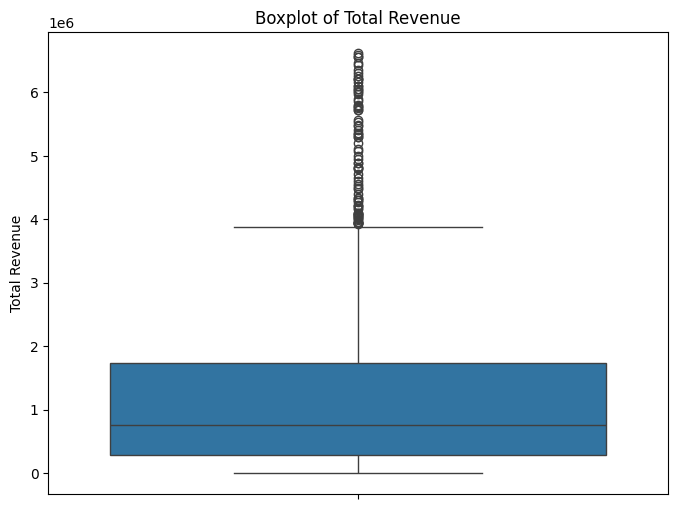

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Total Revenue'])
plt.title('Boxplot of Total Revenue')
plt.ylabel('Total Revenue')
plt.show()

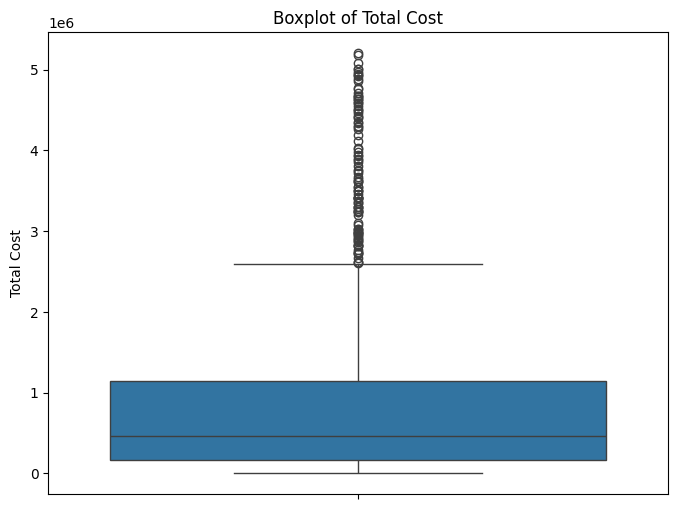

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Total Cost'])
plt.title('Boxplot of Total Cost')
plt.ylabel('Total Cost')
plt.show()

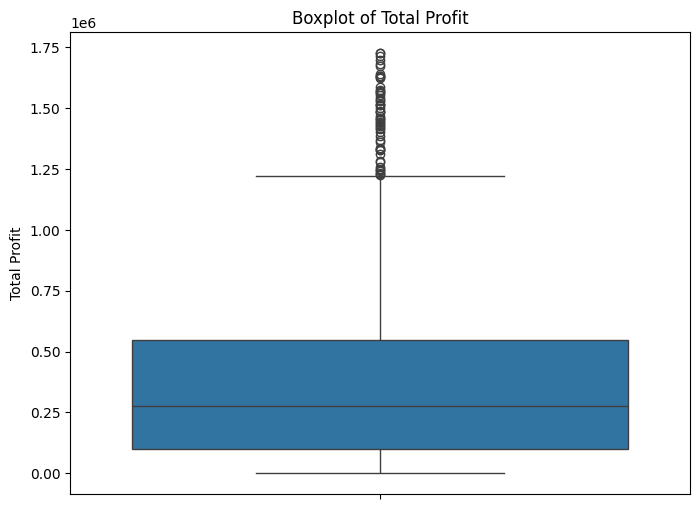

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Total Profit'])
plt.title('Boxplot of Total Profit')
plt.ylabel('Total Profit')
plt.show()

## **Eksplorasi Data (EDA)**

### **Comparison/Perbandingan**

Aktivitas : Membandingkan total nominal penjualan (Total Revenue) di setiap wilayah (Region).

Tujuan : Mengidentifikasi wilayah mana yang memberikan kontribusi pendapatan terbesar dan membandingkan performa antar wilayah secara langsung.

Visualisasi : Bar Chart (Grafik Batang)

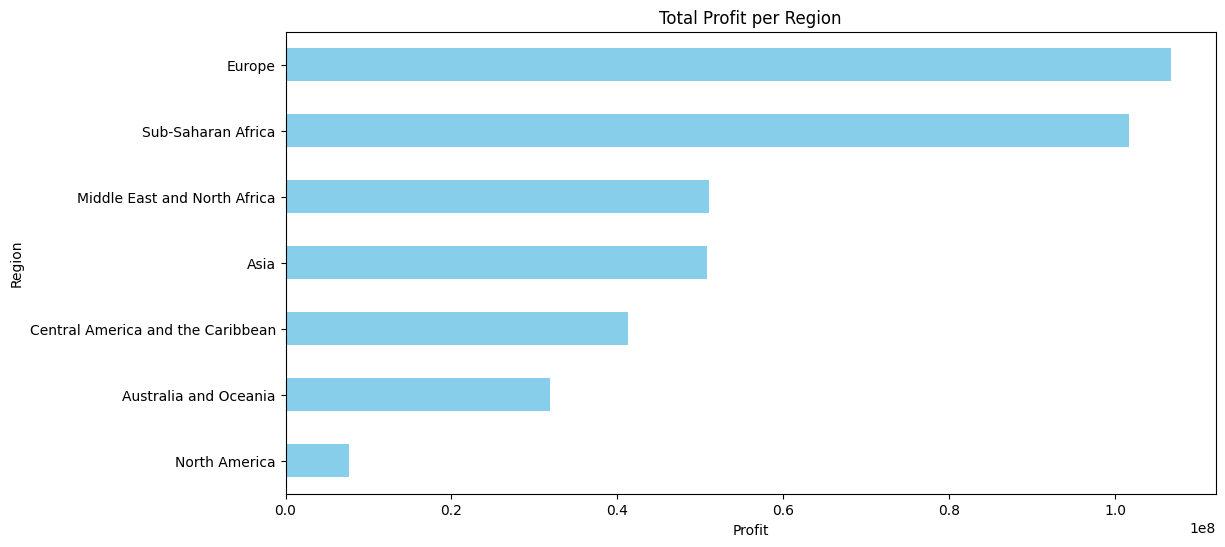

In [ ]:
plt.figure(figsize=(12,6))
df.groupby('Region')['Total Profit'].sum().sort_values().plot(kind='barh', color='skyblue')
plt.title('Total Profit per Region')
plt.xlabel('Profit')
plt.show()

Wilayah Sub-Saharan Africa dan Europe secara konsisten menyumbang profit tertinggi dibandingkan wilayah lainnya, menunjukkan fokus pasar utama perusahaan berada di sana.

### **Composition/Komposisi**

Aktivitas : Melihat proporsi atau persentase total penjualan (Total Revenue) berdasarkan kategori produk (Item Type).

Tujuan : Mengetahui kategori produk mana yang paling mendominasi portofolio penjualan perusahaan secara keseluruhan.

Visualisasi : Pie Chart (Grafik Lingkaran)

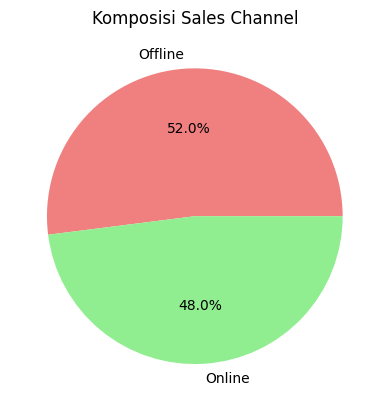

In [ ]:
df['Sales Channel'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['lightcoral', 'lightgreen'])
plt.title('Komposisi Sales Channel')
plt.ylabel('')
plt.show()

Distribusi antara penjualan Online dan Offline hampir seimbang (mendekati 50:50). Perusahaan memiliki strategi omnichannel yang stabil dan tidak bergantung pada satu kanal saja.

### **Distribution/Distribusi**

Aktivitas : Menganalisis penyebaran nilai transaksi pada kolom Total Revenue.

Tujuan : Melihat apakah mayoritas transaksi bernilai kecil atau besar, serta mendeteksi adanya kecondongan (skewness) dalam data penjualan.

Visualisasi : Histogram

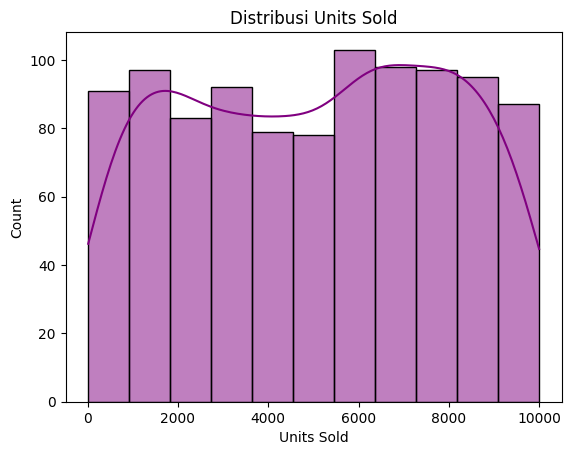

In [ ]:
sns.histplot(df['Units Sold'], kde=True, color='purple')
plt.title('Distribusi Units Sold')
plt.show()

Distribusi Units Sold cenderung Uniform (merata). Artinya, pesanan yang masuk memiliki jumlah unit yang bervariasi secara acak dari angka kecil hingga besar tanpa ada penumpukan di volume tertentu.

### **Relationship/Hubungan**

Aktivitas : Menganalisis korelasi antara nilai penjualan (Total Revenue) dengan keuntungan (Total Profit).

Tujuan : Mengetahui apakah peningkatan penjualan selalu berbanding lurus dengan peningkatan profit, serta mengidentifikasi apakah ada potensi transaksi dengan revenue tinggi tetapi profit rendah.

Visualisasi : Heatmap

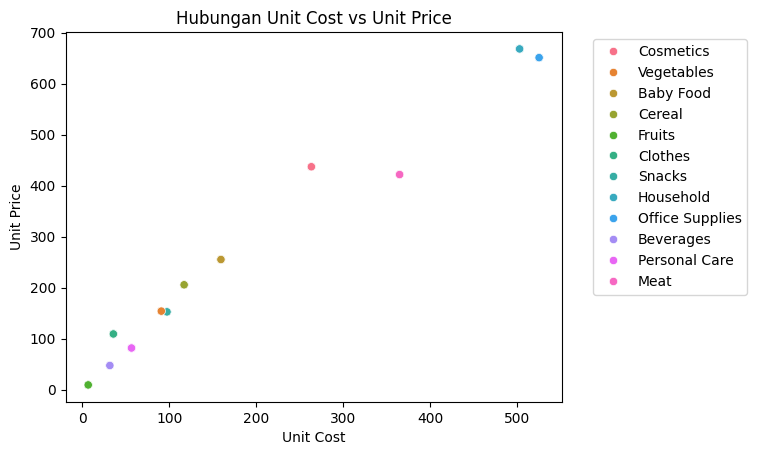

In [ ]:
sns.scatterplot(x='Unit Cost', y='Unit Price', data=df, hue='Item Type')
plt.title('Hubungan Unit Cost vs Unit Price')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Terdapat korelasi positif linear yang sempurna. Hal ini wajar karena harga jual (Price) biasanya ditentukan berdasarkan biaya produksi (Cost) ditambah margin tertentu. Setiap kategori barang memiliki harga tersendiri.

## **Data Preparation**

### **Data Type**

### **Incosistent Values**

Menampilkan nilai unik dari setiap kolom dan untuk melihat apakah ada inconsisten data

In [ ]:
print(df['Region'].unique())
print(df['Country'].unique())
print(df['Item Type'].unique())
print(df['Sales Channel'].unique())
print(df['Order Priority'].unique())
print(df['Order Date'].unique())
print(df['Order ID'].unique())
print(df['Ship Date'].unique())
print(df['Units Sold'].unique())
print(df['Unit Price'].unique())
print(df['Unit Cost'].unique())
print(df['Total Revenue'].unique())
print(df['Total Cost'].unique())
print(df['Total Profit'].unique())
print(df['Order year'].unique())
print(df['Order Month'].unique())
print(df['Order Weekday'].unique())
print(df['Unit Margin'].unique())
print(df['Order_Ship_Days'].unique())

['Middle East and North Africa' 'North America' 'Asia'
 'Sub-Saharan Africa' 'Europe' 'Central America and the Caribbean'
 'Australia and Oceania']
['Libya' 'Canada' 'Japan' 'Chad' 'Armenia' 'Eritrea' 'Montenegro'
 'Jamaica' 'Fiji' 'Togo' 'Greece' 'Sudan' 'Maldives' 'Estonia' 'Greenland'
 'Cape Verde' 'Senegal' 'Federated States of Micronesia' 'Bulgaria'
 'Algeria' 'Mongolia' 'Grenada' 'Mauritius ' 'Morocco' 'Honduras' 'Benin'
 'Equatorial Guinea' 'Swaziland' 'Trinidad and Tobago' 'Sweden' 'Belarus'
 'Guinea-Bissau' 'Turkey' 'Central African Republic' 'Laos' 'Israel'
 'Bhutan' 'Vanuatu' 'Burundi' 'Ukraine' 'Croatia' 'Madagascar' 'Malaysia'
 'Uzbekistan' 'Italy' 'Nepal' 'Portugal' 'Panama' 'Botswana' 'Tanzania'
 'Romania' 'Mali' 'Niger' 'Austria' 'India' 'Luxembourg' 'Iceland' 'Qatar'
 'South Sudan' 'United Kingdom' 'Tunisia ' 'United States of America'
 'Liberia' 'South Korea' 'Kenya' 'Rwanda' 'Cuba' 'Czech Republic'
 'Philippines' 'El Salvador' 'Tonga' 'Democratic Republic of the Cong

Order Date diubah menjadi tipe datetime karena kolom ini digunakan untuk menganalisis waktu terjadinya transaksi seperti tren penjualan per bulan atau per tahun.

In [ ]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="mixed")
df["Order Date"].head(5)

,Order Date
0,2014-10-18
1,2011-11-07
2,2016-10-31
3,2010-04-10
4,2011-08-16


Ship Date diubah menjadi tipe datetime karena kolom ini diperlukan untuk menghitung durasi pengiriman serta mengevaluasi performa distribusi berdasarkan waktu pengiriman.

In [ ]:
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="mixed")
df["Ship Date"].head(5)

,Ship Date
0,2014-10-31
1,2011-12-08
2,2016-12-09
3,2010-05-12
4,2011-08-31


Saya memilih Order Weekday karena isinya berupa teks nama hari yang bisa saja penulisannya beda-beda antara huruf kecil dan besar, jadi perlu diseragamkan supaya tidak terbaca sebagai data yang berbeda saat dianalisis.

In [ ]:
df['Order Weekday'] = df['Order Weekday'].str.upper()
print(df['Order Weekday'].unique())

['FRI' 'SUN' 'MON' 'TUE' 'WED' 'SAT' 'THUR']


### **Missing Values**

Mengecek dataset apakah terdapat missing values.

In [ ]:
print((df.isna().sum() / len(df)) * 100)

Region             0.0
Country            0.0
Item Type          0.0
Sales Channel      0.0
Order Priority     0.0
Order Date         0.0
Order ID           0.0
Ship Date          0.0
Units Sold         0.0
Unit Price         0.0
Unit Cost          0.0
Total Revenue      0.0
Total Cost         0.0
Total Profit       0.0
Order year         0.0
Order Month        0.0
Order Weekday      0.0
Unit Margin        0.0
Order_Ship_Days    0.0
dtype: float64


Dataset ini tidak memiliki missing values karena setiap kolom sudah terisi lengkap tanpa ada data kosong, sehingga proses analisis bisa dilakukan tanpa perlu tahap penanganan data hilang.

In [ ]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio %'])

,Null Ratio %
Region,0.0
Country,0.0
Item Type,0.0
Sales Channel,0.0
Order Priority,0.0
Order Date,0.0
Order ID,0.0
Ship Date,0.0
Units Sold,0.0
Unit Price,0.0


### **Duplicated Values**

Kode ini dipakai untuk menampilkan data yang terduplikasi.

In [ ]:
df[df.duplicated()]

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,Order year,Order Month,Order Weekday,Unit Margin,Order_Ship_Days


Dataset ini juga tidak memiliki duplicate values karena tidak ditemukan baris data yang sama persis, sehingga data yang digunakan sudah bersih dan tidak menyebabkan perhitungan menjadi ganda atau bias dalam analisis.

### **Outliers Values**

Mengecheck persetase outliers pada setiap kolom.

In [ ]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
Order ID,0.0
Units Sold,0.0
Unit Price,0.0
Unit Cost,0.0
Total Revenue,8.6
Total Cost,10.7
Total Profit,5.5
Order year,0.0
Order Month,0.0
Unit Margin,0.0


Terdapat 3 outliers pada kolom Total Revenue, Total Cost, dan Total Profit ditangani dengan metode clipping, yaitu membatasi nilai yang terlalu tinggi atau terlalu rendah agar tetap berada dalam batas wajar.

In [ ]:
columns_to_impute = ["Total Revenue", "Total Cost", "Total Profit"]

for col in columns_to_impute:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Menggunakan .loc[] agar tidak muncul SettingWithCopyWarning
    df.loc[:, col] = df[col].clip(lower=lower_bound, upper=upper_bound)

Pengecekan ulang dilakukan untuk memastikan bahwa proses penanganan outliers berhasil dan tidak ada lagi nilai ekstrem yang bisa mengganggu hasil analisis selanjutnya.

In [ ]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
Order ID,0.0
Units Sold,0.0
Unit Price,0.0
Unit Cost,0.0
Total Revenue,0.0
Total Cost,0.0
Total Profit,0.0
Order year,0.0
Order Month,0.0
Unit Margin,0.0


## **Construct Data**

Menambahkan kolom Profit Category dengan tujuan mengelompokkan transaksi berdasarkan besar kecilnya keuntungan dengan manfaat memudahkan melihat transaksi mana yang paling menguntungkan tanpa harus melihat angka satu per satu.

In [ ]:
def categorize_profit(profit):
    if profit < df['Total Profit'].quantile(0.33):
        return 'Low Profit'
    elif profit < df['Total Profit'].quantile(0.66):
        return 'Medium Profit'
    else:
        return 'High Profit'

df['Profit Category'] = df['Total Profit'].apply(categorize_profit)

Mengecek kolom baru yang telah ditambahkan.

In [ ]:
print(df.columns)

Index(['Region', 'Country', 'Item Type', 'Sales Channel', 'Order Priority',
       'Order Date', 'Order ID', 'Ship Date', 'Units Sold', 'Unit Price',
       'Unit Cost', 'Total Revenue', 'Total Cost', 'Total Profit',
       'Order year', 'Order Month', 'Order Weekday', 'Unit Margin',
       'Order_Ship_Days'],
      dtype='object')


## **Data Reduction**

Menghapus Order Month dan Order Year dikarenakan di dataset ini terdapat Order Date dalam format datetime maka Order Month dan Order Year menjadi tidak terlalu diperlukan karena informasi tersebut bisa di-generate kembali kapan saja dari Order Date.

In [ ]:
df = df.drop('Order Month', axis=1)

In [ ]:
df = df.drop('Order year', axis=1)

Mengecek kolom baru yang telah dihapus.

In [ ]:
print(df.columns)

Index(['Region', 'Country', 'Item Type', 'Sales Channel', 'Order Priority',
       'Order Date', 'Order ID', 'Ship Date', 'Units Sold', 'Unit Price',
       'Unit Cost', 'Total Revenue', 'Total Cost', 'Total Profit',
       'Order Weekday', 'Unit Margin', 'Order_Ship_Days'],
      dtype='object')


## **Menyimpan Dataset (Bersih)**

In [ ]:
df.to_csv('[Bersih]New 1000 Sales Records.csv', index=False)